# The Safest Neighborhood in Pittsburgh

## CS 1520 Final Project Combined Notebook

**Team Name:** Pittsburgh Health and Safety Unit 
**Team Members:** Joey Maslanka, Eric Wang, Warren Schrader  
**Canvas Group:** Group 8

### Project question
For our final project, we wanted to answer a more specific version of the course question, **“What is the best neighborhood in Pittsburgh?”** Instead of trying to define “best” in a broad way, we focused on **safety**. We built a combined metric using three different datasets:

1. **Crime incidents**: fewer reported incidents is better  
2. **Condemned properties**: fewer condemned properties is better  
3. **Lead exposure / water-related health risk**: lower elevated blood lead level percentages is better  

Our goal was to combine these three sub-metrics into one safety score and then rank Pittsburgh neighborhoods from safest to least safe.

## Why we chose this metric

We decided that a safe neighborhood should score well across multiple categories, not just one. A neighborhood with low crime but serious housing issues or elevated blood lead levels would not feel truly safe overall. Because of that, we used **equal weighting** across all three categories.

### Important note about the water dataset
The updated water-related dataset is reported by **census tract**, while the crime and condemned-property datasets are reported by **neighborhood**. To combine them, we created an approximate tract-to-neighborhood mapping by using the most common neighborhood attached to each census tract in the crime data. This is not a perfect geographic crosswalk, but it gives us a reasonable way to merge the datasets and clearly improves on the earlier version where the water score became 0 for everything.

To avoid giving an unfair advantage to neighborhoods with missing values, the final ranking below only includes neighborhoods that had usable data in all three datasets.

In [25]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print(os.getcwd())

c:\Users\Joey\Desktop\School\CS1520\CS-1520-Final-Project\CS-1520-Final-Project


## Load the datasets

These are the three files used in our final combined notebook:

- `crime.csv`
- `condemned_properties.csv`
- `pittsburgh_water_quality.csv.csv`

In [28]:
crime = pd.read_csv("individual_notebooks/data/crime.csv", low_memory=False)
condemned = pd.read_csv("individual_notebooks/data/condemned_properties.csv")
water = pd.read_csv("individual_notebooks/data/pittsburgh_water_quality.csv.csv")

print("Crime shape:", crime.shape)
print("Condemned shape:", condemned.shape)
print("Water shape:", water.shape)

Crime shape: (89038, 20)
Condemned shape: (1000, 16)
Water shape: (395, 15)


## Clean the neighborhood names

The datasets use slightly different neighborhood formatting, so we standardize names before grouping and merging.

In [29]:
def normalize_name(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().rstrip(",")
    value = value.replace("–", "-").replace("—", "-")
    value = " ".join(value.split())
    return value

crime["Neighborhood"] = crime["Neighborhood"].apply(normalize_name)
condemned["neighborhood"] = condemned["neighborhood"].apply(normalize_name)
crime["Tract"] = pd.to_numeric(crime["Tract"], errors="coerce")

print("Crime neighborhoods:", crime["Neighborhood"].nunique())
print("Condemned neighborhoods:", condemned["neighborhood"].nunique())

Crime neighborhoods: 92
Condemned neighborhoods: 71


## Sub-metric 1: Crime incidents by neighborhood

For the crime metric, we simply count the number of incidents in each neighborhood. Since we are measuring safety, **lower values are better**.

In [30]:
crime_by_neighborhood = (
    crime.groupby("Neighborhood")
         .size()
         .reset_index(name="crime_incidents")
         .sort_values("crime_incidents", ascending=True)
)

crime_by_neighborhood.head(10)

,Neighborhood,crime_incidents
21,Chartiers City,5
79,St. Clair,12
68,Saint Clair,25
67,Ridgemont,40
20,Chartiers,49
55,New Homestead,61
83,Swisshelm Park,76
27,East Carnegie,80
82,Summer Hill,94
31,Esplen,104


## Sub-metric 2: Condemned properties by neighborhood

For the housing-condition metric, we count how many condemned properties appear in each neighborhood. Again, **lower values are better**.

In [31]:
condemned_by_neighborhood = (
    condemned.groupby("neighborhood")
             .size()
             .reset_index(name="condemned_properties")
             .sort_values("condemned_properties", ascending=True)
)

condemned_by_neighborhood.head(10)

,neighborhood,condemned_properties
2,Banksville,1
13,Central Business District,1
26,Glen Hazel,1
16,Chateau,1
50,Point Breeze,1
56,South Shore,1
62,St. Clair,1
45,New Homestead,1
67,Upper Lawrenceville,1
44,Mt. Oliver,2


## Sub-metric 3: Water / lead exposure risk by neighborhood

The updated lead dataset is reported by **census tract**, not neighborhood. To make it usable in the combined notebook:

1. We convert the census tract codes in the lead dataset into the local tract numbers used in the crime dataset.
2. We use the **most common neighborhood** associated with each tract in the crime data as an approximate tract-to-neighborhood crosswalk.
3. We average `percentEBLL15_20` for each neighborhood.

Here, **lower lead-rate values are better**.

In [32]:
tract_counts = (
    crime.dropna(subset=["Tract", "Neighborhood"])
         .groupby(["Tract", "Neighborhood"])
         .size()
         .reset_index(name="incident_count")
         .sort_values(["Tract", "incident_count"], ascending=[True, False])
)

tract_to_neighborhood = tract_counts.drop_duplicates("Tract")[["Tract", "Neighborhood"]]

water["tract_local"] = water["CensusTract"].astype(str).str[-6:].astype(int) / 100

water_mapped = water.merge(
    tract_to_neighborhood,
    left_on="tract_local",
    right_on="Tract",
    how="left"
)

water_by_neighborhood = (
    water_mapped.dropna(subset=["Neighborhood"])
               .groupby("Neighborhood", as_index=False)["percentEBLL15_20"]
               .mean()
               .rename(columns={"percentEBLL15_20": "lead_rate"})
               .sort_values("lead_rate", ascending=True)
)

print("Water rows mapped to a neighborhood:", water_mapped["Neighborhood"].notna().sum(), "out of", len(water_mapped))
water_by_neighborhood.head(10)

Water rows mapped to a neighborhood: 109 out of 395


,Neighborhood,lead_rate
57,Strip District,0.000
64,West Oakland,0.000
59,Swisshelm Park,0.000
58,Summer Hill,0.000
37,New Homestead,0.000
29,Lincoln Place,0.480
50,South Side Flats,0.600
40,Overbrook,0.865
60,Terrace Village,0.880
1,Banksville,0.950


## Combine the three sub-metrics

To make the three datasets comparable, we convert each raw metric into a **0 to 1 score**, where:

- **1 = safest**
- **0 = least safe**

Because lower raw values are better in all three categories, each score is computed as:

\[
\text{score} = 1 - \frac{x - \min(x)}{\max(x) - \min(x)}
\]

Then we average the three scores equally to create an overall safety score.

In [33]:
combined = (
    crime_by_neighborhood
    .merge(condemned_by_neighborhood, left_on="Neighborhood", right_on="neighborhood", how="inner")
    .drop(columns="neighborhood")
    .merge(water_by_neighborhood, on="Neighborhood", how="inner")
)

for col in ["crime_incidents", "condemned_properties", "lead_rate"]:
    minimum = combined[col].min()
    maximum = combined[col].max()
    combined[f"{col}_score"] = 1 - ((combined[col] - minimum) / (maximum - minimum))

combined["overall_safety_score"] = combined[
    ["crime_incidents_score", "condemned_properties_score", "lead_rate_score"]
].mean(axis=1)

ranked = combined.sort_values("overall_safety_score", ascending=False).reset_index(drop=True)

print("Neighborhoods included in final ranking:", len(ranked))
ranked.head(10)

Neighborhoods included in final ranking: 55


,Neighborhood,crime_incidents,condemned_properties,lead_rate,crime_incidents_score,condemned_properties_score,lead_rate_score,overall_safety_score
0,New Homestead,61,1,0.000,1.000000,1.000000,1.000000,1.000000
1,West Oakland,453,4,0.000,0.956785,0.950820,1.000000,0.969202
2,Banksville,410,1,0.950,0.961526,1.000000,0.932957,0.964828
3,Terrace Village,633,3,0.880,0.936942,0.967213,0.937897,0.947351
4,Stanton Heights,270,2,1.945,0.976960,0.983607,0.862738,0.941101
5,Overbrook,518,7,0.865,0.949620,0.901639,0.938956,0.930072
6,Point Breeze,641,1,2.245,0.936060,1.000000,0.841567,0.925876
7,Lincoln Place,315,11,0.480,0.971999,0.836066,0.966126,0.924730
8,Morningside,242,2,4.130,0.980046,0.983607,0.708539,0.890731
9,Lower Lawrenceville,467,2,3.820,0.955242,0.983607,0.730416,0.889755


## Top 10 safest neighborhoods

The table below shows the ten highest-ranked neighborhoods according to our combined safety metric.

In [34]:
top10 = ranked[["Neighborhood", "crime_incidents", "condemned_properties", "lead_rate", "overall_safety_score"]].head(10)
top10

,Neighborhood,crime_incidents,condemned_properties,lead_rate,overall_safety_score
0,New Homestead,61,1,0.000,1.000000
1,West Oakland,453,4,0.000,0.969202
2,Banksville,410,1,0.950,0.964828
3,Terrace Village,633,3,0.880,0.947351
4,Stanton Heights,270,2,1.945,0.941101
5,Overbrook,518,7,0.865,0.930072
6,Point Breeze,641,1,2.245,0.925876
7,Lincoln Place,315,11,0.480,0.924730
8,Morningside,242,2,4.130,0.890731
9,Lower Lawrenceville,467,2,3.820,0.889755


## Visualization: Top 10 overall safety scores

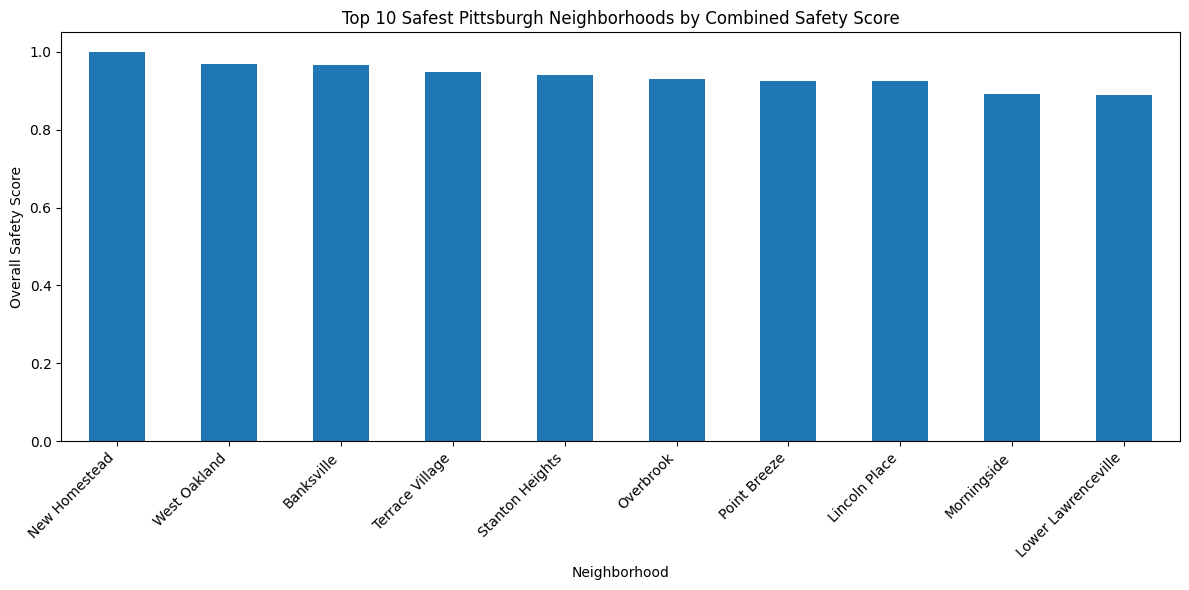

In [35]:
ax = ranked.head(10).plot(
    kind="bar",
    x="Neighborhood",
    y="overall_safety_score",
    legend=False,
    figsize=(12, 6)
)
ax.set_title("Top 10 Safest Pittsburgh Neighborhoods by Combined Safety Score")
ax.set_ylabel("Overall Safety Score")
ax.set_xlabel("Neighborhood")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visualization: Comparing the winner across the three raw metrics

In [36]:
winner = ranked.iloc[0]
winner_name = winner["Neighborhood"]

winner_row = ranked.loc[
    ranked["Neighborhood"] == winner_name,
    ["Neighborhood", "crime_incidents", "condemned_properties", "lead_rate"]
]

winner_row

,Neighborhood,crime_incidents,condemned_properties,lead_rate
0,New Homestead,61,1,0.0


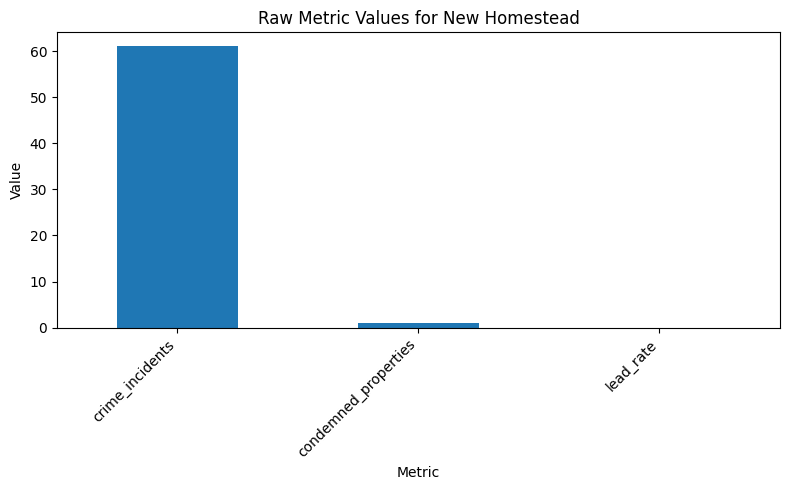

In [37]:
winner_metrics = winner_row.set_index("Neighborhood").T

ax = winner_metrics.plot(kind="bar", legend=False, figsize=(8, 5))
ax.set_title(f"Raw Metric Values for {winner_name}")
ax.set_ylabel("Value")
ax.set_xlabel("Metric")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Final result: the safest neighborhood

According to our equal-weight combined safety metric, **New Homestead** ranks as the safest neighborhood in Pittsburgh in this notebook.

Why New Homestead finished first:
- It had the **lowest crime count** among the neighborhoods that had data in all three datasets.
- It had only **1 condemned property** in the condemned-properties dataset.
- Its mapped `percentEBLL15_20` value was **0.0**, which gave it the best lead-risk score in our combined metric.

This does **not** mean New Homestead is objectively the safest place under every possible definition. It means that, **using our three chosen datasets and our equal-weight scoring method**, New Homestead earned the highest overall score.

In [38]:
ranked.head(15)

,Neighborhood,crime_incidents,condemned_properties,lead_rate,crime_incidents_score,condemned_properties_score,lead_rate_score,overall_safety_score
0,New Homestead,61,1,0.000000,1.000000,1.000000,1.000000,1.000000
1,West Oakland,453,4,0.000000,0.956785,0.950820,1.000000,0.969202
2,Banksville,410,1,0.950000,0.961526,1.000000,0.932957,0.964828
3,Terrace Village,633,3,0.880000,0.936942,0.967213,0.937897,0.947351
4,Stanton Heights,270,2,1.945000,0.976960,0.983607,0.862738,0.941101
5,Overbrook,518,7,0.865000,0.949620,0.901639,0.938956,0.930072
6,Point Breeze,641,1,2.245000,0.936060,1.000000,0.841567,0.925876
7,Lincoln Place,315,11,0.480000,0.971999,0.836066,0.966126,0.924730
8,Morningside,242,2,4.130000,0.980046,0.983607,0.708539,0.890731
9,Lower Lawrenceville,467,2,3.820000,0.955242,0.983607,0.730416,0.889755


## Conclusion

Our group defined “best” as **safest**, and we measured safety using three sub-metrics: crime incidents, condemned properties, and lead exposure risk. After cleaning the datasets, mapping census tracts to neighborhoods, and normalizing each sub-metric into a common score, **New Homestead** came out on top.

One thing we learned during this project is that combining datasets is often the hardest part of data analysis. The updated water dataset was much better than the earlier one, but it still needed extra work because it was reported by tract instead of by neighborhood. Even with that limitation, the final notebook gives us a clear, data-driven way to compare neighborhoods.

### Individual reflection placeholders
**Joey:** Working on this project helped me understand how messy real data can be and how much work goes into actually combining different datasets. The hardest part for me was dealing with the water data since it used census tracts instead of neighborhoods, so we had to figure out a way to match them up. That made me realize that data analysis isn’t just running code, it’s also figuring out how to make different data sources work together.

Looking at the final results, I probably wouldn’t have guessed that New Homestead would come out as the safest neighborhood just based on personal opinion. But after seeing the data, it makes sense because it had low crime, very few condemned properties, and a low lead risk score.

Overall, this project helped me get more comfortable with pandas, working with multiple datasets, and building a full notebook from start to finish with others through the use of github. It also gave me a better understanding of how data can be used to support an argument instead of just showing numbers.  

**Eric:** This water quality analysis taught me the value of converting census tract-level data into neighborhood-level insights, a process that required careful data merging and cleaning to ensure accuracy. Working through this challenge helped me improve my pandas skills and understand how to make raw data accessible for team analysis.
Seeing how lead exposure risk factored into the final neighborhood ranking, with New Homestead ranking top due to its low lead levels, reinforced how public health metrics are essential to a holistic livability assessment. This project also strengthened my ability to collaborate on GitHub and align my work with the team’s overall project goals.  

**Warren:** [Write Warren's conclusion paragraph here.]